In [1]:
# prompt: let's upload heards_structured_cleaned_04.csv

from google.colab import files
uploaded = files.upload()

Saving heards_structured_cleaned_04.csv to heards_structured_cleaned_04.csv


Successfully loaded 'heards_structured_cleaned_04.csv'. Shape: (195672, 16)

--- Performing Sanity Checks ---

Found 19789 rows with 'action_type' = 'No Trade'.
                                             headline       price
16  Platts FUJ HSFO 380CST: Jun 27-Jul 2 pegged at...  348.806070
17  Platts FUJ HSFO 380CST: Jun 22-Jun 26 pegged a...  366.379342
18  Platts FUJ HSFO 380CST: Jun 17-Jun 21 pegged a...  366.379342
19  Platts FUJ HSFO 380CST: Jun 12-Jun 16 pegged a...  366.379342
20  Platts HSFO 380CST: Jun 17-Jun 22 pegged at MO...  366.379342
Sanity Check Passed: 'No Trade' entries generally have null volume_min/max (as expected).

Missing values in key columns for 'No Trade' entries:
price_basis      19789
grade              130
incoterm         11932
location          8104
frequency_tag    19789
dtype: int64
Observation: Missing values in these columns for 'No Trade' entries are expected as they are not actual trades.


--- Starting Exploratory Data Analysis (EDA) ---

1. Dat

<ipython-input-2-53cde7e4979b>:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='action_type', data=df, order=df['action_type'].value_counts().index, ax=axes[3], palette='viridis')
<ipython-input-2-53cde7e4979b>:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='party', data=df[df['party'].isin(top_parties)], order=top_parties, ax=axes[4], palette='plasma')
<ipython-input-2-53cde7e4979b>:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='location', data=df, order=df['location'].value_counts().index, ax=axes[5], palette='civid

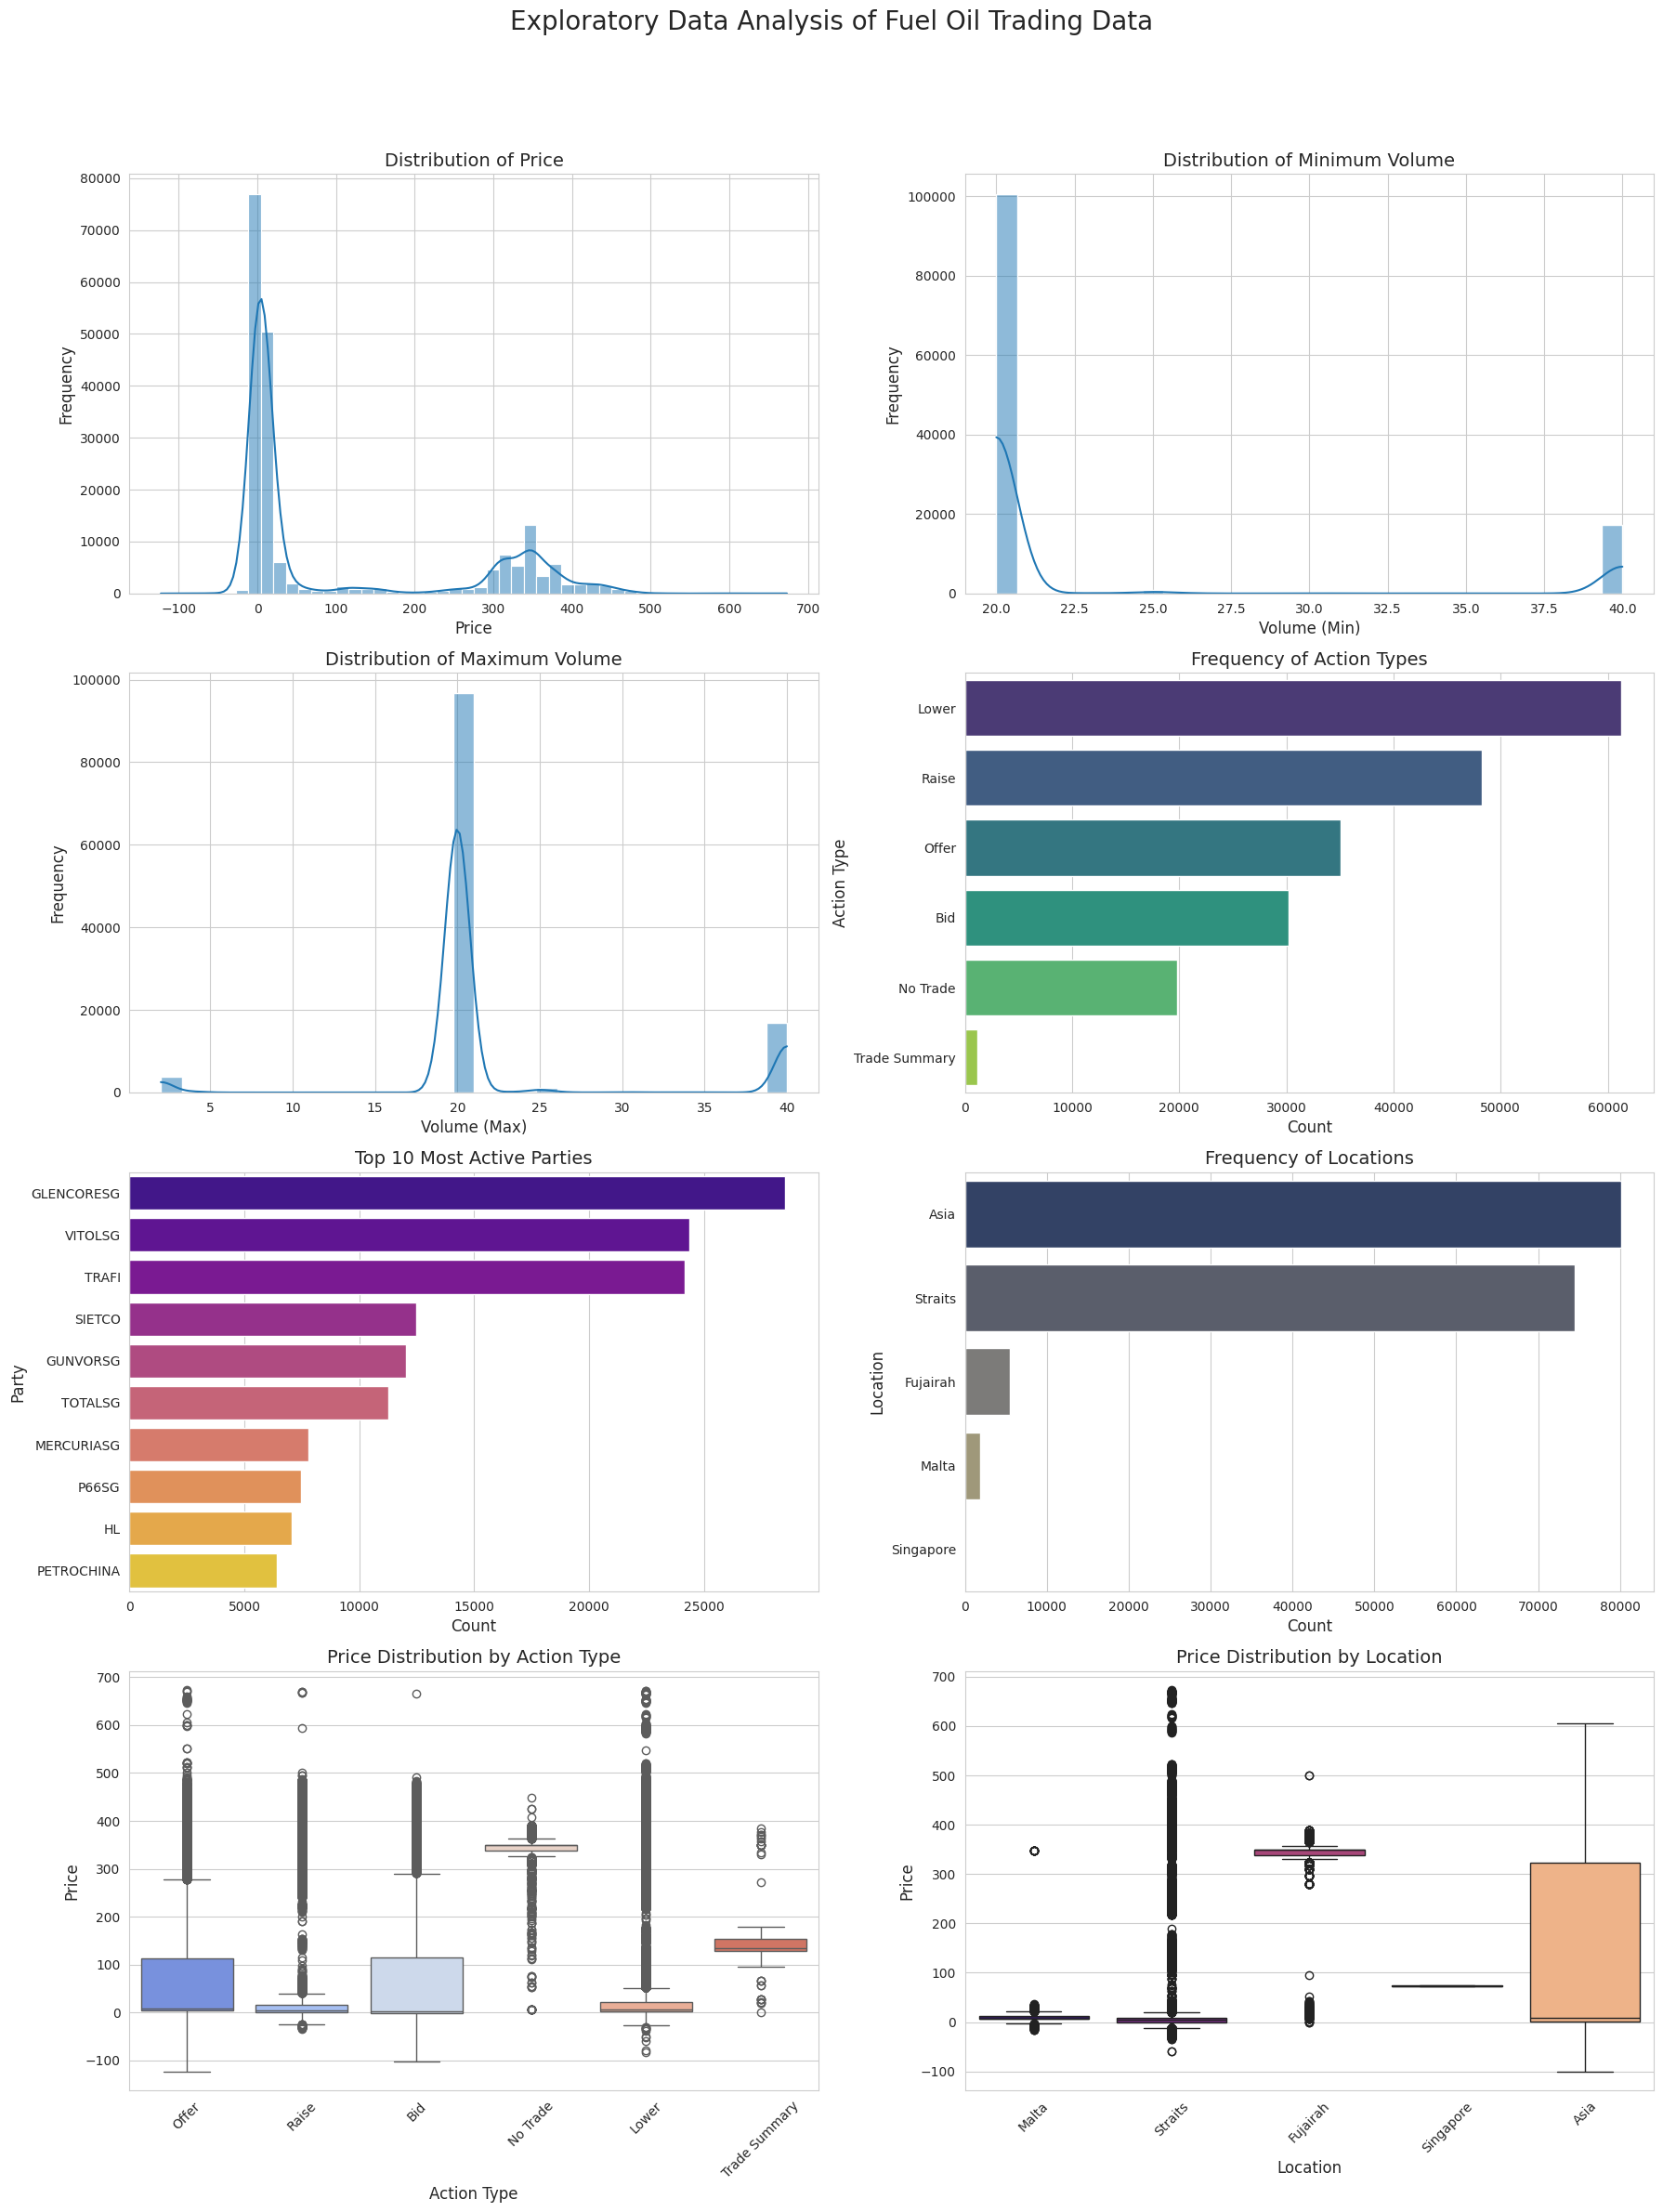


--- EDA Complete ---


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Configuration ---
FILE_PATH = 'heards_structured_cleaned_04.csv' # Make sure this file is in the same directory as your script

# --- Load the dataset ---
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded '{FILE_PATH}'. Shape: {df.shape}\n")
except FileNotFoundError:
    print(f"Error: The file '{FILE_PATH}' was not found. Please ensure it's in the correct directory.")
    exit()

# --- Sanity Checks ---
print("--- Performing Sanity Checks ---\n")

# 1. Check 'No Trade' entries for price, volume_min, volume_max
no_trade_df = df[df['action_type'] == 'No Trade']
print(f"Found {len(no_trade_df)} rows with 'action_type' = 'No Trade'.")

# Check if 'price' is NaN or 0 for 'No Trade' entries
no_trade_price_issues = no_trade_df[no_trade_df['price'].notna() & (no_trade_df['price'] != 0)]
if not no_trade_price_issues.empty:
    print(f"Warning: {len(no_trade_price_issues)} 'No Trade' entries have a non-zero price.")
    print(no_trade_price_issues[['headline', 'price']].head())
else:
    print("Sanity Check Passed: 'No Trade' entries generally have no price or a price of 0 (as expected).")

# Check if 'volume_min' and 'volume_max' are NaN for 'No Trade' entries
no_trade_volume_issues = no_trade_df[no_trade_df['volume_min'].notna() | no_trade_df['volume_max'].notna()]
if not no_trade_volume_issues.empty:
    print(f"Warning: {len(no_trade_volume_issues)} 'No Trade' entries have non-null volume_min/max.")
    print(no_trade_volume_issues[['headline', 'volume_min', 'volume_max']].head())
else:
    print("Sanity Check Passed: 'No Trade' entries generally have null volume_min/max (as expected).")

# 2. Check for consistency in other fields for 'No Trade' entries (e.g., price_basis, incoterm, location)
# These might be legitimately missing or varied, but it's good to observe.
print("\nMissing values in key columns for 'No Trade' entries:")
print(no_trade_df[['price_basis', 'grade', 'incoterm', 'location', 'frequency_tag']].isnull().sum())
print("Observation: Missing values in these columns for 'No Trade' entries are expected as they are not actual trades.\n")


# --- Exploratory Data Analysis (EDA) ---
print("\n--- Starting Exploratory Data Analysis (EDA) ---\n")

# 1. Data Information and Missing Values
print("1. Dataset Information and Missing Values:\n")
df.info()

print("\nMissing values percentage per column:")
missing_percentage = df.isnull().sum() / len(df) * 100
print(missing_percentage.sort_values(ascending=False))

# 2. Descriptive Statistics for Numerical Columns
print("\n2. Descriptive Statistics for Numerical Columns:\n")
print(df[['price', 'volume_min', 'volume_max']].describe())

# 3. Value Counts for Categorical Columns
print("\n3. Value Counts for Categorical Columns:\n")
categorical_cols = ['action_type', 'party', 'price_basis', 'grade', 'incoterm', 'location', 'frequency_tag', 'source']
for col in categorical_cols:
    print(f"\n--- Value Counts for '{col}' ---")
    print(df[col].value_counts(dropna=False)) # Include NaN counts

# --- Visualizations ---
print("\n--- Generating Visualizations ---")

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Inter' # Set font to Inter

# Create a figure with subplots for better organization
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 24))
fig.suptitle('Exploratory Data Analysis of Fuel Oil Trading Data', fontsize=20, y=1.02)
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Plot 1: Histogram of Price
sns.histplot(df['price'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Price', fontsize=14)
axes[0].set_xlabel('Price', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Plot 2: Histogram of Volume_Min
sns.histplot(df['volume_min'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Minimum Volume', fontsize=14)
axes[1].set_xlabel('Volume (Min)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

# Plot 3: Histogram of Volume_Max
sns.histplot(df['volume_max'].dropna(), bins=30, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Maximum Volume', fontsize=14)
axes[2].set_xlabel('Volume (Max)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)

# Plot 4: Bar Plot of Action Type Frequencies
sns.countplot(y='action_type', data=df, order=df['action_type'].value_counts().index, ax=axes[3], palette='viridis')
axes[3].set_title('Frequency of Action Types', fontsize=14)
axes[3].set_xlabel('Count', fontsize=12)
axes[3].set_ylabel('Action Type', fontsize=12)

# Plot 5: Bar Plot of Top 10 Parties
top_parties = df['party'].value_counts().nlargest(10).index
sns.countplot(y='party', data=df[df['party'].isin(top_parties)], order=top_parties, ax=axes[4], palette='plasma')
axes[4].set_title('Top 10 Most Active Parties', fontsize=14)
axes[4].set_xlabel('Count', fontsize=12)
axes[4].set_ylabel('Party', fontsize=12)

# Plot 6: Bar Plot of Location Frequencies
sns.countplot(y='location', data=df, order=df['location'].value_counts().index, ax=axes[5], palette='cividis')
axes[5].set_title('Frequency of Locations', fontsize=14)
axes[5].set_xlabel('Count', fontsize=12)
axes[5].set_ylabel('Location', fontsize=12)

# Plot 7: Box Plot of Price by Action Type
sns.boxplot(x='action_type', y='price', data=df, ax=axes[6], palette='coolwarm')
axes[6].set_title('Price Distribution by Action Type', fontsize=14)
axes[6].set_xlabel('Action Type', fontsize=12)
axes[6].set_ylabel('Price', fontsize=12)
axes[6].tick_params(axis='x', rotation=45) # Rotate labels for readability

# Plot 8: Box Plot of Price by Location
sns.boxplot(x='location', y='price', data=df, ax=axes[7], palette='magma')
axes[7].set_title('Price Distribution by Location', fontsize=14)
axes[7].set_xlabel('Location', fontsize=12)
axes[7].set_ylabel('Price', fontsize=12)
axes[7].tick_params(axis='x', rotation=45) # Rotate labels for readability

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

print("\n--- EDA Complete ---")

In [3]:
# --- Display the first 5 rows of the DataFrame ---
print("First 5 rows of the DataFrame:")
print(df.head())


First 5 rows of the DataFrame:
               updatedDate  start_date    end_date action_type  party  price  \
0  2025-05-23 14:44:56.674  2025-06-02  2025-06-06       Offer   GLTD   16.0   
1  2025-05-23 08:28:59.221  2025-06-17  2025-06-21       Raise  TRAFI    2.5   
2  2025-05-23 08:27:41.104  2025-06-17  2025-06-21       Raise  TRAFI    2.0   
3  2025-05-23 08:26:22.775  2025-06-17  2025-06-21       Raise  TRAFI    1.5   
4  2025-05-23 08:23:43.738  2025-06-17  2025-06-21       Raise  TRAFI    1.0   

  price_basis  grade incoterm location  volume_min  volume_max frequency_tag  \
0           3    NaN      CIF    Malta         NaN         NaN       Any Day   
1    MOPS 380  380.0      FOB  Straits        20.0        20.0       BalMnth   
2    MOPS 380  380.0      FOB  Straits        20.0        20.0       BalMnth   
3    MOPS 380  380.0      FOB  Straits        20.0        20.0       BalMnth   
4    MOPS 380  380.0      FOB  Straits        20.0        20.0       BalMnth   

  sourc

In [4]:
# --- Convert date columns to datetime objects ---
date_columns = ['updatedDate', 'start_date', 'end_date']
print(f"Converting columns {date_columns} to datetime objects...\n")

for col in date_columns:
    # errors='coerce' will turn any unparseable date strings into NaT (Not a Time)
    # This is useful for handling any malformed date entries gracefully.
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("--- Data types after date conversion ---")
df.info()

print("\n--- First 5 rows of the DataFrame after date conversion ---")
print(df.head())


Converting columns ['updatedDate', 'start_date', 'end_date'] to datetime objects...

--- Data types after date conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   updatedDate    118750 non-null  datetime64[ns]
 1   start_date     174894 non-null  datetime64[ns]
 2   end_date       178263 non-null  datetime64[ns]
 3   action_type    195672 non-null  object        
 4   party          178357 non-null  object        
 5   price          195672 non-null  float64       
 6   price_basis    158335 non-null  object        
 7   grade          174502 non-null  float64       
 8   incoterm       160850 non-null  object        
 9   location       161898 non-null  object        
 10  volume_min     119534 non-null  float64       
 11  volume_max     119534 non-null  float64       
 12  frequency_tag  118892 non-null

In [7]:
import pandas as pd

# Assume 'df' is your DataFrame *after* the date conversion has been performed.
# If you are running this in a new Colab session, you would first need to load
# your CSV and perform the date conversion as done previously.

# Load the original CSV into a temporary DataFrame to compare row counts
FILE_PATH = 'heards_structured_cleaned_04.csv'
try:
    df_original_check = pd.read_csv(FILE_PATH)
except FileNotFoundError:
    print(f"Error: The file '{FILE_PATH}' was not found. Please ensure it's uploaded.")
    exit()

print("--- Checking for Lost Rows ---")
print(f"Original DataFrame rows: {len(df_original_check)}")
print(f"Current DataFrame (after date conversion) rows: {len(df)}")

if len(df_original_check) == len(df):
    print("\nConfirmation: No rows were lost during the date conversion process.")
    print("Unparseable date strings were converted to 'NaT' (Not a Time) within their existing rows.")
else:
    print("\nWarning: The number of rows has changed. Investigate further.")

# Clean up the temporary DataFrame
del df_original_check

# --- Added: Check Data Types ---
print("\n--- Current DataFrame Data Types ---")
df.info()
print(df.head())

--- Checking for Lost Rows ---
Original DataFrame rows: 195672
Current DataFrame (after date conversion) rows: 195672

Confirmation: No rows were lost during the date conversion process.
Unparseable date strings were converted to 'NaT' (Not a Time) within their existing rows.

--- Current DataFrame Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   updatedDate    118750 non-null  datetime64[ns]
 1   start_date     174894 non-null  datetime64[ns]
 2   end_date       178263 non-null  datetime64[ns]
 3   action_type    195672 non-null  object        
 4   party          178357 non-null  object        
 5   price          195672 non-null  float64       
 6   price_basis    158335 non-null  object        
 7   grade          174502 non-null  float64       
 8   incoterm       160850 non-null  object        
 9

In [8]:
# Calculate the percentage of filled rows for each column
# This is equivalent to (total rows - null rows) / total rows * 100
percentage_filled = (df.notnull().sum() / len(df)) * 100

print("Percentage of filled rows for each column:")
print(percentage_filled.sort_values(ascending=False))

Percentage of filled rows for each column:
action_type      100.000000
price            100.000000
headline         100.000000
party             91.151008
source            91.151008
id                91.151008
end_date          91.102968
start_date        89.381209
grade             89.180874
location          82.739482
incoterm          82.203892
price_basis       80.918578
volume_max        61.088965
volume_min        61.088965
frequency_tag     60.760865
updatedDate       60.688295
dtype: float64


In [13]:
import pandas as pd

# --- Configuration ---
FILE_PATH = 'heards_structured_cleaned_04.csv'

# --- Load the dataset ---
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Successfully loaded '{FILE_PATH}'. Shape: {df.shape}\n")
except FileNotFoundError:
    print(f"Error: The file '{FILE_PATH}' was not found. Please ensure it's uploaded to Colab.")
    exit()

# --- Iterative Date Conversion for updatedDate ---
print("Attempting iterative date conversion for 'updatedDate' with multiple formats...\n")

# 1. Strip whitespace from the column first
df['updatedDate'] = df['updatedDate'].astype(str).str.strip()

# 2. First attempt: Parse with milliseconds format
df['updatedDate_parsed'] = pd.to_datetime(df['updatedDate'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

# 3. Second attempt: For values that failed in the first attempt (are NaT), try parsing without milliseconds
# Identify indices where parsing failed in the first attempt
failed_indices = df['updatedDate_parsed'].isna()

# Apply the second format only to the original strings at these failed indices
df.loc[failed_indices, 'updatedDate_parsed'] = pd.to_datetime(
    df.loc[failed_indices, 'updatedDate'], # Use original string values for failed ones
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

# Replace the original 'updatedDate' column with the newly parsed one
df['updatedDate'] = df['updatedDate_parsed']

# Drop the temporary parsed column
df = df.drop(columns=['updatedDate_parsed'])


# --- Process 'start_date' and 'end_date' (these formats seemed consistent) ---
print("Converting 'start_date' and 'end_date'...\n")
df['start_date'] = df['start_date'].astype(str).str.strip()
df['end_date'] = df['end_date'].astype(str).str.strip()

df['start_date'] = pd.to_datetime(df['start_date'], format='%Y-%m-%d', errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], format='%Y-%m-%d', errors='coerce')


print("--- Data types after iterative date conversion ---")
df.info()

print("\n--- First 5 rows of the DataFrame after iterative date conversion ---")
print(df.head())

print("\n--- Non-null counts (percentage filled) after iterative date conversion ---")
percentage_filled = df.notna().sum() / len(df) * 100
print(percentage_filled.sort_values(ascending=False))

# Optional: Check if any 'updatedDate' values still became NaT and print samples
print("\n--- Sample of original 'updatedDate' strings that still could not be parsed (if any) ---")
# To get the original strings, we need to reload or keep a copy of the original df
df_original_for_check = pd.read_csv(FILE_PATH)
df_original_for_check['updatedDate'] = df_original_for_check['updatedDate'].astype(str).str.strip()

still_nat_updated_date_indices = df[df['updatedDate'].isna()].index

if not still_nat_updated_date_indices.empty:
    print(df_original_for_check.loc[still_nat_updated_date_indices, 'updatedDate'].head(10).to_string())
    print(f"\nStill {len(still_nat_updated_date_indices)} 'updatedDate' entries became NaT.")
else:
    print("All 'updatedDate' values were parsed successfully!")

Successfully loaded 'heards_structured_cleaned_04.csv'. Shape: (195672, 16)

Attempting iterative date conversion for 'updatedDate' with multiple formats...

Converting 'start_date' and 'end_date'...

--- Data types after iterative date conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   updatedDate    195672 non-null  datetime64[ns]
 1   start_date     174894 non-null  datetime64[ns]
 2   end_date       178263 non-null  datetime64[ns]
 3   action_type    195672 non-null  object        
 4   party          178357 non-null  object        
 5   price          195672 non-null  float64       
 6   price_basis    158335 non-null  object        
 7   grade          174502 non-null  float64       
 8   incoterm       160850 non-null  object        
 9   location       161898 non-null  object        
 10  volume_m

In [15]:

# --- Randomly sample 100 rows and print them, isolating the date columns ---
print("--- Randomly Sampled 100 Rows of the DataFrame (Date Columns Only) ---")
print(df.sample(n=100)[['updatedDate', 'start_date', 'end_date']])


--- Randomly Sampled 100 Rows of the DataFrame (Date Columns Only) ---
                   updatedDate start_date   end_date
30832  2023-08-08 04:02:31.857 2025-09-02 2025-09-06
125198 2019-02-25 08:27:04.000 2025-03-12 2025-03-16
127742 2019-01-11 08:24:03.000 2025-02-01 2025-02-05
176938 2017-07-04 07:46:14.000        NaT 2025-08-07
94255  2020-03-26 07:55:55.911 2025-04-15 2025-04-19
...                        ...        ...        ...
84393  2020-09-01 08:26:59.498 2025-09-18 2025-09-22
9488   2024-11-07 07:52:41.429 2025-12-02 2025-12-07
87377  2020-07-13 07:17:57.245 2025-08-12 2025-08-16
63852  2021-09-02 08:22:30.060 2025-09-17 2025-09-21
153021 2018-04-02 07:59:57.000 2025-04-27 2025-05-01

[100 rows x 3 columns]


In [16]:

# Calculate the percentage of filled rows for each column
percentage_filled = (df.notnull().sum() / len(df)) * 100

print("\nPercentage of filled rows for each column:")
print(percentage_filled.sort_values(ascending=False))

# Print the data types of each column
print("\nData types of each column:")
df.dtypes


Percentage of filled rows for each column:
updatedDate      100.000000
action_type      100.000000
price            100.000000
headline         100.000000
source            91.151008
id                91.151008
party             91.151008
end_date          91.102968
start_date        89.381209
grade             89.180874
location          82.739482
incoterm          82.203892
price_basis       80.918578
volume_min        61.088965
volume_max        61.088965
frequency_tag     60.760865
dtype: float64

Data types of each column:


,0
updatedDate,datetime64[ns]
start_date,datetime64[ns]
end_date,datetime64[ns]
action_type,object
party,object
price,float64
price_basis,object
grade,float64
incoterm,object
location,object



--- Analyzing Source Frequencies ---

Source Value Counts (including NaN):
source
regex    145120
model     33237
NaN       17315
Name: count, dtype: int64


<ipython-input-17-139cabb5f693>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='source', data=df, order=source_counts.index, palette='tab10')


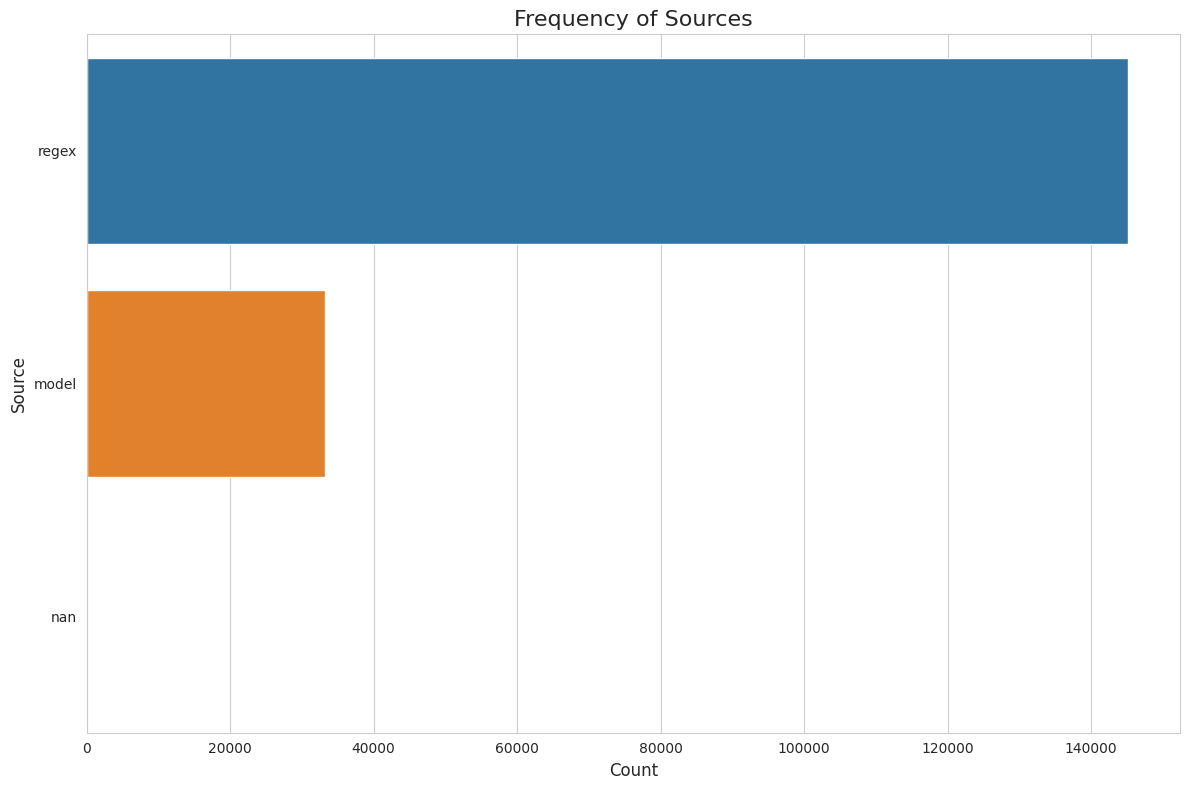


Found 17315 rows with missing 'source' information (NaN).

Most Common Sources:
source
regex    145120
model     33237
NaN       17315
Name: count, dtype: int64


In [17]:


# 4. Bar Plot of Source Frequencies
print("\n--- Analyzing Source Frequencies ---")
source_counts = df['source'].value_counts(dropna=False)
print("\nSource Value Counts (including NaN):")
print(source_counts)

plt.figure(figsize=(12, 8))
sns.countplot(y='source', data=df, order=source_counts.index, palette='tab10')
plt.title('Frequency of Sources', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Source', fontsize=12)
plt.tight_layout()
plt.show()

# Check if NaN is present and report its count
if source_counts.get(np.nan, 0) > 0:
    print(f"\nFound {source_counts[np.nan]} rows with missing 'source' information (NaN).")

# Print the most common sources
print("\nMost Common Sources:")
print(source_counts.head())

In [20]:

# Display column names, non-null counts, and data types
print("\n--- Column Information ---")
df.info()

# Calculate and display the percentage of filled rows for each column
percentage_filled = (df.notnull().sum() / len(df)) * 100
print("\nPercentage of filled rows for each column:")
print(percentage_filled.sort_values(ascending=False))

# Display the data types of each column
print("\nData types of each column:")
df.dtypes


--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   updatedDate    195672 non-null  datetime64[ns]
 1   start_date     174894 non-null  datetime64[ns]
 2   end_date       178263 non-null  datetime64[ns]
 3   action_type    195672 non-null  object        
 4   party          178357 non-null  object        
 5   price          195672 non-null  float64       
 6   price_basis    158335 non-null  object        
 7   grade          174502 non-null  float64       
 8   incoterm       160850 non-null  object        
 9   location       161898 non-null  object        
 10  volume_min     119534 non-null  float64       
 11  volume_max     119534 non-null  float64       
 12  frequency_tag  118892 non-null  object        
 13  headline       195672 non-null  object        
 14  id             178357 no

,0
updatedDate,datetime64[ns]
start_date,datetime64[ns]
end_date,datetime64[ns]
action_type,object
party,object
price,float64
price_basis,object
grade,float64
incoterm,object
location,object


In [21]:
df = df.drop(columns=['id'])
print("The 'id' column has been dropped.")
print("\nRemaining columns:")
print(df.columns)

The 'id' column has been dropped.

Remaining columns:
Index(['updatedDate', 'start_date', 'end_date', 'action_type', 'party',
       'price', 'price_basis', 'grade', 'incoterm', 'location', 'volume_min',
       'volume_max', 'frequency_tag', 'headline'],
      dtype='object')


In [22]:
# Display column names, non-null counts, and data types
print("\n--- Column Information ---")
df.info()

# Calculate and display the percentage of filled rows for each column
percentage_filled = (df.notnull().sum() / len(df)) * 100
print("\nPercentage of filled rows for each column:")
print(percentage_filled.sort_values(ascending=False))

# Display the data types of each column
print("\nData types of each column:")
df.dtypes


--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   updatedDate    195672 non-null  datetime64[ns]
 1   start_date     174894 non-null  datetime64[ns]
 2   end_date       178263 non-null  datetime64[ns]
 3   action_type    195672 non-null  object        
 4   party          178357 non-null  object        
 5   price          195672 non-null  float64       
 6   price_basis    158335 non-null  object        
 7   grade          174502 non-null  float64       
 8   incoterm       160850 non-null  object        
 9   location       161898 non-null  object        
 10  volume_min     119534 non-null  float64       
 11  volume_max     119534 non-null  float64       
 12  frequency_tag  118892 non-null  object        
 13  headline       195672 non-null  object        
dtypes: datetime64[ns](3), fl

,0
updatedDate,datetime64[ns]
start_date,datetime64[ns]
end_date,datetime64[ns]
action_type,object
party,object
price,float64
price_basis,object
grade,float64
incoterm,object
location,object


In [23]:


# --- Randomly sample 10 rows and print them ---
print("\n--- Randomly Sampled 10 Rows of the DataFrame ---")
print(df.sample(n=10))


--- Randomly Sampled 10 Rows of the DataFrame ---
                   updatedDate start_date   end_date action_type       party  \
87623  2020-07-07 08:17:17.638 2025-08-02 2025-08-06       Raise       MIPCO   
141177 2018-08-06 08:18:11.000 2025-08-27 2025-08-31       Raise  PETROCHINA   
54183  2022-03-16 07:59:39.404 2025-04-09 2025-04-13       Offer        BPSG   
106260 2019-09-17 08:17:30.000 2025-10-17 2025-10-21         Bid     TOTALSG   
148701 2018-05-31 08:28:53.000 2025-06-25 2025-06-29       Lower  GLENCORESG   
14089  2024-08-08 03:08:10.136 2025-08-28 2025-09-01    No Trade  GLENCORESG   
49573  2022-05-31 08:07:22.098 2025-06-15 2025-06-19       Lower        BPSG   
25194  2023-12-20 07:59:41.692 2025-01-09 2025-01-13       Offer      SIETCO   
74375  2021-03-12 08:28:59.392 2025-04-01 2025-04-05         Bid  GLENCORESG   
34111  2023-05-10 08:20:46.653 2025-05-25 2025-05-29       Raise       P66SG   

             price price_basis  grade incoterm location  volume_min 

In [25]:

# Identify rows where 'action_type' is 'No Trade' AND ('price' is null OR ('volume_min' is null AND 'volume_max' is null))
# Note: Based on previous checks, 'No Trade' rows should ideally have price=0/NaN and volume=NaN.
# This check focuses specifically on rows marked 'No Trade' that also have missing *or zero* volume.
# Adjusting the condition based on the earlier sanity checks:
# - 'price' is NaN OR 'price' is 0
# - 'volume_min' is NaN
# - 'volume_max' is NaN

# Condition for rows with 'No Trade' action type
no_trade_condition = (df['action_type'] == 'No Trade')

# Condition for rows where price is NaN or 0 AND (volume_min is NaN OR volume_max is NaN)
# Since the sanity check confirmed 'No Trade' should have NaN volume, let's focus on price AND volume NaNs/zeros for 'No Trade'.
# A row is considered "empty or Null for price AND/OR Volume" in the context of "No Trade" if:
# (price is NaN OR price is 0) AND (volume_min is NaN OR volume_max is NaN)

# Let's refine the condition to match the request:
# Find rows where:
# 1. action_type is 'No Trade'
# 2. AND (price is NaN OR price is 0)
# 3. AND (volume_min is NaN OR volume_max is NaN)

# Condition for empty/null price (including zero for 'No Trade' context)
price_empty_or_null = df['price'].isna() | (df['price'] == 0)

# Condition for empty/null volume (either min or max is NaN)
volume_empty_or_null = df['volume_min'].isna() | df['volume_max'].isna()

# Combine the conditions
rows_matching_criteria = df[
    no_trade_condition &
    price_empty_or_null &
    volume_empty_or_null
]

# Print the number of rows matching the criteria
print(f"\nNumber of rows with 'No Trade' action type AND (price is NaN/0 AND volume_min/max is NaN): {len(rows_matching_criteria)}")

# Optionally, display some of these rows
if not rows_matching_criteria.empty:
    print("\nSample of rows matching the criteria:")
    print(rows_matching_criteria[['headline', 'action_type', 'price', 'volume_min', 'volume_max']].head())
else:
    print("\nNo rows found matching the specific criteria.")

# A slightly different interpretation based on "empty or Null for price AND/OR Volume":
# Find rows where:
# 1. action_type is 'No Trade'
# 2. AND ((price is NaN OR price is 0) OR (volume_min is NaN OR volume_max is NaN))
# This second interpretation captures 'No Trade' rows that are missing *either* price (or price is 0) *or* volume.
# Given the earlier sanity checks confirmed price=0/NaN and volume=NaN for 'No Trade' are expected, the first interpretation is likely what's intended (rows that *are* 'No Trade' and *confirm* the expected missing data pattern).
# However, if you want to find 'No Trade' rows that are *missing something* from price/volume (even if the other is present), use this second interpretation:

print("\n--- Alternative Check: 'No Trade' rows with Price/Volume issues ---")
# Find rows where:
# 1. action_type is 'No Trade'
# 2. AND ((price is NaN OR price is 0) OR (volume_min is NaN OR volume_max is NaN))

alternative_rows_matching_criteria = df[
    no_trade_condition &
    (price_empty_or_null | volume_empty_or_null) # OR condition
]

print(f"\nNumber of rows with 'No Trade' action type AND (price is NaN/0 OR volume_min/max is NaN): {len(alternative_rows_matching_criteria)}")

if not alternative_rows_matching_criteria.empty:
    print("\nSample of rows matching the alternative criteria:")
    print(alternative_rows_matching_criteria[['headline', 'action_type', 'price', 'volume_min', 'volume_max']].head())
else:
    print("\nNo rows found matching the alternative criteria.")

# Based on the earlier sanity checks, the first definition (where both price AND volume conditions are met for 'No Trade')
# is the more specific check confirming the expected state of 'No Trade' entries. The second definition
# finds any 'No Trade' entry that is missing *either* price or volume, which should ideally be all of them.
# The first count is likely what you are looking for: 'No Trade' entries that properly reflect no price AND no volume.

print("\n--- Summary of relevant counts ---")
print(f"Total rows with 'action_type' = 'No Trade': {len(no_trade_df)}")
print(f"Rows where 'action_type' is 'No Trade' AND (price is NaN/0 AND volume_min/max is NaN): {len(rows_matching_criteria)}")
print(f"Rows where 'action_type' is 'No Trade' AND (price is NaN/0 OR volume_min/max is NaN): {len(alternative_rows_matching_criteria)}")



Number of rows with 'No Trade' action type AND (price is NaN/0 AND volume_min/max is NaN): 0

No rows found matching the specific criteria.

--- Alternative Check: 'No Trade' rows with Price/Volume issues ---

Number of rows with 'No Trade' action type AND (price is NaN/0 OR volume_min/max is NaN): 19789

Sample of rows matching the alternative criteria:
                                             headline action_type       price  \
16  Platts FUJ HSFO 380CST: Jun 27-Jul 2 pegged at...    No Trade  348.806070   
17  Platts FUJ HSFO 380CST: Jun 22-Jun 26 pegged a...    No Trade  366.379342   
18  Platts FUJ HSFO 380CST: Jun 17-Jun 21 pegged a...    No Trade  366.379342   
19  Platts FUJ HSFO 380CST: Jun 12-Jun 16 pegged a...    No Trade  366.379342   
20  Platts HSFO 380CST: Jun 17-Jun 22 pegged at MO...    No Trade  366.379342   

    volume_min  volume_max  
16         NaN         NaN  
17         NaN         NaN  
18         NaN         NaN  
19         NaN         NaN  
20        

In [27]:
# --- Check for Negative Values ---
print("\n--- Checking for Negative Values ---")

# Check 'price' for negative values
negative_price = df[df['price'] < 0]
if not negative_price.empty:
    print(f"\nFound {len(negative_price)} rows with negative 'price':")
    print(negative_price[['headline', 'price']].head())
else:
    print("\nNo negative values found in 'price'.")

# Check 'volume_min' for negative values
negative_volume_min = df[df['volume_min'] < 0]
if not negative_volume_min.empty:
    print(f"\nFound {len(negative_volume_min)} rows with negative 'volume_min':")
    print(negative_volume_min[['headline', 'volume_min']].head())
else:
    print("\nNo negative values found in 'volume_min'.")

# Check 'volume_max' for negative values
negative_volume_max = df[df['volume_max'] < 0]
if not negative_volume_max.empty:
    print(f"\nFound {len(negative_volume_max)} rows with negative 'volume_max':")
    print(negative_volume_max[['headline', 'volume_max']].head())
else:
    print("\nNo negative values found in 'volume_max'.")


# --- Check for Outliers using IQR ---
print("\n--- Checking for Outliers using IQR ---")

numerical_cols = ['price', 'volume_min', 'volume_max']

for col in numerical_cols:
    print(f"\nAnalyzing outliers for column: '{col}'")

    # Calculate Q1, Q3, and IQR, excluding NaNs
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers (excluding NaNs as they are not outliers in the traditional sense)
    outliers = df[(df[col].notna()) & ((df[col] < lower_bound) | (df[col] > upper_bound))]

    if not outliers.empty:
        print(f"Found {len(outliers)} potential outliers in '{col}'.")
        print(f"  (Values outside the range [{lower_bound:.2f}, {upper_bound:.2f}])")
        print("Sample of outliers:")
        print(outliers[['headline', col]].head())
    else:
        print(f"No significant outliers found in '{col}' using the IQR method.")

# Note: The IQR method is a common approach, but the definition of an outlier can vary.
# Visualizations like box plots (which you already generated) are also very helpful
# for visually identifying the spread and potential outliers.


--- Checking for Negative Values ---

Found 23255 rows with negative 'price':
                                             headline  price
6   Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...   -1.0
7   Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...   -2.0
8   Platts HSFO 380cst FOB Straits 15-30, TRAFI bi...   -3.0
13  Platts HSFO 380cst FOB Straits 15-30, GLENCORE...   -5.0
15  Platts HSFO 380cst FOB Straits 15-30, GLENCORE...   -5.0

No negative values found in 'volume_min'.

No negative values found in 'volume_max'.

--- Checking for Outliers using IQR ---

Analyzing outliers for column: 'price'
No significant outliers found in 'price' using the IQR method.

Analyzing outliers for column: 'volume_min'
Found 19019 potential outliers in 'volume_min'.
  (Values outside the range [20.00, 20.00])
Sample of outliers:
                                             headline  volume_min
13  Platts HSFO 380cst FOB Straits 15-30, GLENCORE...        40.0
14  Platts HSFO 380cst FOB Straits 1

<ipython-input-28-4f87f32576b7>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='action_type', data=negative_price_df, order=action_type_counts.index, palette='viridis')



--- Analyzing Action Types for Negative Prices ---

Value counts of 'action_type' for rows with negative 'price':
action_type
Raise    9951
Bid      8027
Lower    4420
Offer     857
Name: count, dtype: int64

Sample of rows with negative prices and their action types:
                                             headline action_type  price
6   Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...       Raise   -1.0
7   Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...       Raise   -2.0
8   Platts HSFO 380cst FOB Straits 15-30, TRAFI bi...         Bid   -3.0
13  Platts HSFO 380cst FOB Straits 15-30, GLENCORE...         Bid   -5.0
15  Platts HSFO 380cst FOB Straits 15-30, GLENCORE...         Bid   -5.0
28  Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...       Raise   -0.5
29  Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...       Raise   -1.5
36  Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...       Raise   -2.5
39  Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...       Raise   -3.5


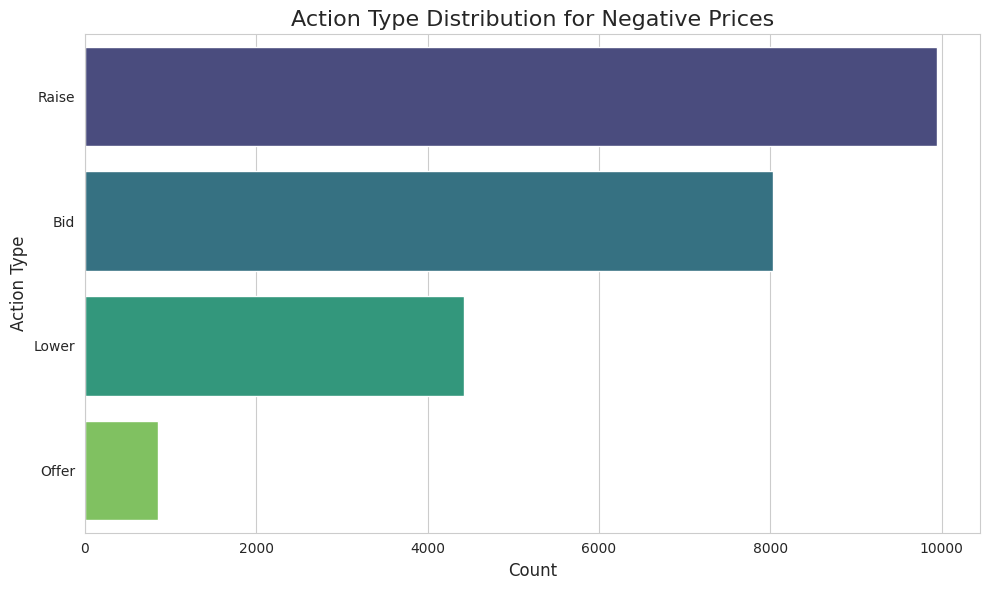

In [28]:
# Filter the DataFrame to include only rows with negative prices
negative_price_df = df[df['price'] < 0].copy() # Use .copy() to avoid SettingWithCopyWarning

print("\n--- Analyzing Action Types for Negative Prices ---")

if not negative_price_df.empty:
    # Get the value counts for 'action_type' within the negative price rows
    action_type_counts = negative_price_df['action_type'].value_counts(dropna=False)

    print("\nValue counts of 'action_type' for rows with negative 'price':")
    print(action_type_counts)

    # Optional: Display a sample of these rows including action_type and price
    print("\nSample of rows with negative prices and their action types:")
    print(negative_price_df[['headline', 'action_type', 'price']].head(10))

    # Optional: Visualize the distribution of action types for negative prices
    plt.figure(figsize=(10, 6))
    sns.countplot(y='action_type', data=negative_price_df, order=action_type_counts.index, palette='viridis')
    plt.title('Action Type Distribution for Negative Prices', fontsize=16)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Action Type', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("\nNo rows with negative prices found to analyze.")

In [29]:
# Filter the DataFrame to include only rows with negative prices
negative_price_df = df[df['price'] < 0].copy()

print("\n--- Action Type Distribution for Negative Prices ---")

if not negative_price_df.empty:
    # Get the value counts for 'action_type' within the negative price rows
    action_type_counts = negative_price_df['action_type'].value_counts(dropna=False)

    # Convert the value counts to a DataFrame for better table display
    action_type_table = action_type_counts.reset_index()
    action_type_table.columns = ['Action Type', 'Count']

    # Print the table
    print(action_type_table)

else:
    print("\nNo rows with negative prices found to analyze.")


--- Action Type Distribution for Negative Prices ---
  Action Type  Count
0       Raise   9951
1         Bid   8027
2       Lower   4420
3       Offer    857


In [30]:
# Filter the DataFrame to include only rows with negative prices
negative_price_df = df[df['price'] < 0].copy()

print("\n--- Sample Headlines for Negative Prices by Action Type ---")

action_types_to_sample = ['Raise', 'Bid', 'Lower', 'Offer']

for action_type in action_types_to_sample:
    # Filter for rows with the current action type and negative price
    subset_df = negative_price_df[negative_price_df['action_type'] == action_type]

    if not subset_df.empty:
        # Sample one row and print the headline and price
        sample_row = subset_df.sample(n=1)
        headline = sample_row['headline'].iloc[0]
        price = sample_row['price'].iloc[0]
        print(f"\nAction Type: '{action_type}'")
        print(f"  Price: {price}")
        print(f"  Headline: {headline}")
    else:
        print(f"\nNo negative prices found for Action Type: '{action_type}'")


--- Sample Headlines for Negative Prices by Action Type ---

Action Type: 'Raise'
  Price: -0.5
  Headline: Asia 1309: Platts HSFO 380cst FOB Straits 15-30, TRAFI raises bid Sep 23-Sep 27 100% MOPS 380 5 Day $-0.50  for 20-20 8:

Action Type: 'Bid'
  Price: -1.0
  Headline: Asia 220: Platts HSFO 380cst FOB Straits 15-30, MERCURIASG amends bid Sep 8-Sep 12 100% MOPS 380 5 Day $-1.00  for 20-20

Action Type: 'Lower'
  Price: -0.5
  Headline: Asia 1764: Platts HSFO 380cst FOB Straits 15-30, TRAFI lowers offer Jun 1-Jun 5 100% MOPS 380 5 Day $-0.50  for 20-20 "i

Action Type: 'Offer'
  Price: -2.0
  Headline: Platts HSFO 380cst FOB Straits 15-30, CHIMB withdraws offer May 19-May 23 100% MOPS 380 5 Day $-2.00  for 20-20 "++


In [32]:
print("\n--- Detailed Analysis of 'price' by 'action_type' ---")

# Group by 'action_type' and calculate descriptive statistics for 'price'
price_stats_by_action = df.groupby('action_type')['price'].agg([
    'count',
    'mean',
    'std',
    'min',
    lambda x: x.quantile(0.25), # 25th percentile (Q1)
    lambda x: x.quantile(0.50), # 50th percentile (Median)
    lambda x: x.quantile(0.75), # 75th percentile (Q3)
    'max'
])

# Also calculate the count of negative prices for each action type
negative_price_counts = df[df['price'] < 0].groupby('action_type').size().rename('negative_count')

# Merge the two results
price_analysis_table = price_stats_by_action.join(negative_price_counts, how='left').fillna(0)

# Calculate the percentage of negative prices
# Ensure we don't divide by zero if a group has no non-null prices
price_analysis_table['negative_percentage'] = (price_analysis_table['negative_count'] / price_analysis_table['count']) * 100
price_analysis_table['negative_percentage'] = price_analysis_table['negative_percentage'].replace([np.inf, -np.inf], 0) # Handle potential inf if count is 0

# Rename columns for clarity
price_analysis_table.rename(columns={
    'count': 'Non-Null Count',
    'mean': 'Mean Price',
    'std': 'Std Dev Price',
    'min': 'Min Price',
    '<lambda_0>': '25th Percentile (Q1)', # These are the default names for lambda functions
    '<lambda_1>': 'Median Price (Q2)',
    '<lambda_2>': '75th Percentile (Q3)',
    'max': 'Max Price',
    'negative_count': 'Negative Price Count',
    'negative_percentage': 'Negative Price Percentage'
}, inplace=True)

# Display the table
print(price_analysis_table)

# Optional: Sort the table by the number or percentage of negative prices
# print("\n--- Sorted by Negative Price Count ---")
# print(price_analysis_table.sort_values('Negative Price Count', ascending=False))

# print("\n--- Sorted by Negative Price Percentage ---")
# print(price_analysis_table.sort_values('Negative Price Percentage', ascending=False))


--- Detailed Analysis of 'price' by 'action_type' ---
               Non-Null Count  Mean Price  Std Dev Price   Min Price  \
action_type                                                            
Bid                     30162   79.329521     136.257557 -102.825127   
Lower                   61227   70.826192     138.314592  -82.879284   
No Trade                19789  347.782581      21.685882    6.451603   
Offer                   35095   85.626627     132.622119 -122.748891   
Raise                   48268   63.727236     136.260425  -34.000000   
Trade Summary            1131  142.744421      30.653093    1.000000   

               25th Percentile (Q1)  Median Price (Q2)  75th Percentile (Q3)  \
action_type                                                                    
Bid                       -1.000000           2.750000            115.620808   
Lower                      2.000000           6.451603             22.000000   
No Trade                 338.789968         348.

In [33]:
print("\n--- Sample Rows with Negative Prices by Action Type ---")

action_types_with_neg_price = ['Bid', 'Lower', 'Offer', 'Raise']

for action_type in action_types_with_neg_price:
    # Filter for rows with the current action type and negative price
    subset_df = df[(df['action_type'] == action_type) & (df['price'] < 0)]

    if not subset_df.empty:
        # Sample one row
        sample_row = subset_df.sample(n=1)
        print(f"\n--- Action Type: '{action_type}' ---")
        # Print the entire sampled row (or selected columns)
        display(sample_row) # Using display for better formatting in Colab/Jupyter
    else:
        print(f"\nNo negative prices found for Action Type: '{action_type}' to sample.")


--- Sample Rows with Negative Prices by Action Type ---

--- Action Type: 'Bid' ---


,updatedDate,start_date,end_date,action_type,party,price,price_basis,grade,incoterm,location,volume_min,volume_max,frequency_tag,headline
117910,2019-05-29 08:29:27,2025-06-23,2025-06-27,Bid,HL,-2.0,MOPS 380,380.0,FOB,Asia,20.0,20.0,NaN,Asia 1213: Platts HSFO 380cst FOB Straits 15-3...



--- Action Type: 'Lower' ---


,updatedDate,start_date,end_date,action_type,party,price,price_basis,grade,incoterm,location,volume_min,volume_max,frequency_tag,headline
27931,2023-10-11 08:28:44.589,2025-10-26,2025-10-30,Lower,TRAFI,-3.0,MOPS 380,380.0,FOB,Straits,20.0,20.0,BalMnth,"Platts HSFO 380cst FOB Straits 15-30, TRAFI lo..."



--- Action Type: 'Offer' ---


,updatedDate,start_date,end_date,action_type,party,price,price_basis,grade,incoterm,location,volume_min,volume_max,frequency_tag,headline
195294,2017-07-28 08:29:03,NaT,NaT,Offer,NaN,-53.694244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,asia 1686: platts hsfo 380cst fob straits 15-3...



--- Action Type: 'Raise' ---


,updatedDate,start_date,end_date,action_type,party,price,price_basis,grade,incoterm,location,volume_min,volume_max,frequency_tag,headline
98642,2019-11-20 08:11:21,2025-12-16,2025-12-20,Raise,GUNVORSG,-14.0,MOPS 180,380.0,FOB,Asia,NaN,NaN,NaN,Asia 604: Platts HSFO 380cst FOB Straits 15-30...


In [34]:
# Display column names, non-null counts, and data types
print("\n--- Column Information ---")
df.info()

# Calculate and display the percentage of filled rows for each column
percentage_filled = (df.notnull().sum() / len(df)) * 100
print("\nPercentage of filled rows for each column:")
print(percentage_filled.sort_values(ascending=False))

# Display the data types of each column
print("\nData types of each column:")
df.dtypes


--- Column Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195672 entries, 0 to 195671
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   updatedDate    195672 non-null  datetime64[ns]
 1   start_date     174894 non-null  datetime64[ns]
 2   end_date       178263 non-null  datetime64[ns]
 3   action_type    195672 non-null  object        
 4   party          178357 non-null  object        
 5   price          195672 non-null  float64       
 6   price_basis    158335 non-null  object        
 7   grade          174502 non-null  float64       
 8   incoterm       160850 non-null  object        
 9   location       161898 non-null  object        
 10  volume_min     119534 non-null  float64       
 11  volume_max     119534 non-null  float64       
 12  frequency_tag  118892 non-null  object        
 13  headline       195672 non-null  object        
dtypes: datetime64[ns](3), fl

,0
updatedDate,datetime64[ns]
start_date,datetime64[ns]
end_date,datetime64[ns]
action_type,object
party,object
price,float64
price_basis,object
grade,float64
incoterm,object
location,object


In [35]:
import pandas as pd

# Define the output file path
output_file_path = 'heards_structured_cleaned_05.csv'

# Save the DataFrame to a CSV file
# index=False prevents pandas from writing the DataFrame index as a column
df.to_csv(output_file_path, index=False)

print(f"DataFrame successfully saved to '{output_file_path}'")

DataFrame successfully saved to 'heards_structured_cleaned_05.csv'


In [36]:


files.download(output_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>